# Formula Drift Web Scrape and Analysis

In [1]:
import requests
from bs4 import BeautifulSoup as bs
import pandas as pd

Now that we have imported everything we need to webscrape, let's try to see if the website is able to be viewed

In [2]:
url='https://www.formulad.com/standings/2024/pro'
headers = {
    "User-Agent": "Mozilla/5.0"
}
response = requests.get(url,headers=headers)
status = response.status_code
if status == 200:
    page = response.text
    soup = bs(page)
else:
    print(f"Oops! Received status code {status}")

In [19]:
print(soup.prettify())

<!DOCTYPE html>
<html lang="en">
 <head>
  <meta charset="utf-8"/>
  <title>
   Formula DRIFT -     2022 PRO Standings
  </title>
  <meta content="width=device-width, initial-scale=1" name="viewport"/>
  <script src="https://ajax.googleapis.com/ajax/libs/jquery/1.11.3/jquery.min.js">
  </script>
  <meta content="31wzm2vc02dm33wztu9iwfxr31pfpx" name="facebook-domain-verification">
   <script>
    (function(i,s,o,g,r,a,m){i['GoogleAnalyticsObject']=r;i[r]=i[r]||function(){
	(i[r].q=i[r].q||[]).push(arguments)},i[r].l=1*new Date();a=s.createElement(o),
	m=s.getElementsByTagName(o)[0];a.async=1;a.src=g;m.parentNode.insertBefore(a,m)
	})(window,document,'script','https://www.google-analytics.com/analytics.js','ga');

	ga('create', 'UA-3982137-1', 'auto');
	ga('send', 'pageview');
   </script>
   <script>
    !function(f,b,e,v,n,t,s){if(f.fbq)return;n=f.fbq=function(){n.callMethod?
	n.callMethod.apply(n,arguments):n.queue.push(arguments)};if(!f._fbq)f._fbq=n;
	n.push=n;n.loaded=!0;n.version=

It looks like we are able to perform webscraping on this website! We can start collecting data through webscraping (thanks beautiful soup!)

In [3]:
#2024 - generated with help from copilot
url = "https://www.formulad.com/standings/2024/pro"
response = requests.get(url)
soup = bs(response.text, 'html.parser')
tables = soup.find_all("table")
driver_2024 = pd.read_html(str(tables))[0]
driver_2024["Year"] = 2024 #add year column when concatenating different pages

#2023
url = "https://www.formulad.com/standings/2023/pro"
response = requests.get(url)
soup = bs(response.text, 'html.parser')
tables = soup.find_all("table")
driver_2023 = pd.read_html(str(tables))[0]
driver_2023["Year"] = 2023

#2022
url = "https://www.formulad.com/standings/2022/pro"
response = requests.get(url)
soup = bs(response.text, 'html.parser')
tables = soup.find_all("table")
driver_2022 = pd.read_html(str(tables))[0]
driver_2022["Year"] = 2022


driver = pd.concat(
    [driver_2022, driver_2023, driver_2024],
    ignore_index=True
)

driver.head()

,Unnamed: 0_level_0,Unnamed: 1_level_0,Unnamed: 2_level_0,LONG BEACH,ATLANTA,ORLANDO,ENGLISHTOWN,ST. LOUIS,MONROE,GRANTSVILLE,...,SEATTLE,Long Beach,Atlanta,Orlando,Englishtown,St. Louis,Seattle,Grantsville,Irwindale,Unnamed: 13_level_0
,RANK,CAR #,DRIVER,F,F,F,F,F,F,F,...,F,F,F,F,F,F,F,F,F,Unnamed: 13_level_1
0,1,151,Fredric Aasbo Toyota ☑ / Nitto ☑,80.0,101.0,83.0,67.0,52.0,67.0,94.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,777,Matt Field Chevrolet ☑ / Falken ☑,92.0,83.0,80.0,80.0,80.0,91.0,52.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,411,Ryan Tuerck Toyota ☑ / Nitto ☑,103.0,67.0,52.0,67.0,91.0,67.0,35.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,88,Chelsea Denofa Ford ☑ / Nitto ☑,69.0,54.0,69.0,83.0,35.0,102.0,80.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,64,Chris Forsberg Nissan ☑ / GT Radial ☑,67.0,91.0,91.0,52.0,35.0,81.0,67.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
driver.columns

MultiIndex([( 'Unnamed: 0_level_0',                'RANK'),
            ( 'Unnamed: 1_level_0',               'CAR #'),
            ( 'Unnamed: 2_level_0',              'DRIVER'),
            (         'LONG BEACH',                   'F'),
            (            'ATLANTA',                   'F'),
            (            'ORLANDO',                   'F'),
            (        'ENGLISHTOWN',                   'F'),
            (          'ST. LOUIS',                   'F'),
            (             'MONROE',                   'F'),
            (        'GRANTSVILLE',                   'F'),
            (          'IRWINDALE',                   'F'),
            ('Unnamed: 11_level_0',               'TOTAL'),
            ('Unnamed: 12_level_0', 'Unnamed: 12_level_1'),
            (               'Year',                    ''),
            (            'SEATTLE',                   'F'),
            (         'Long Beach',                   'F'),
            (            'Atlanta',     

In [13]:
#2024
url = "https://www.formulad.com/standings/2024/pro"
response = requests.get(url)
soup = bs(response.text, 'html.parser')
tables = soup.find_all("table")
table = tables[1]
manufacturer_2024 = pd.read_html(str(table))[0]
manufacturer_2024["Year"] = 2024

#2023
url = "https://www.formulad.com/standings/2023/pro"
response = requests.get(url)
soup = bs(response.text, 'html.parser')
tables = soup.find_all("table")
table = tables[3]
manufacturer_2023 = pd.read_html(str(table))[0]
manufacturer_2023["Year"] = 2023

#2022
url = "https://www.formulad.com/standings/2022/pro"
response = requests.get(url)
soup = bs(response.text, 'html.parser')
tables = soup.find_all("table")
table = tables[2]
manufacturer_2022 = pd.read_html(str(table))[0]
manufacturer_2022["Year"] = 2022


manufacturers = pd.concat(
    [manufacturer_2022, manufacturer_2023, manufacturer_2024],
    ignore_index=True
)

manufacturers.head(30)

,Unnamed: 0,LONG BEACH,ATLANTA,ORLANDO,ENGLISHTOWN,ST. LOUIS,MONROE,GRANTSVILLE,IRWINDALE,TOTAL,Year,SEATTLE,Long Beach,Atlanta,Orlando,Englishtown,St. Louis,Seattle,Grantsville,Irwindale
0,TOYOTA,183.0,168.0,135.0,134.0,171.0,147.0,194.0,194.0,1326,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CHEVROLET,144.0,118.0,132.0,115.0,115.0,158.0,104.0,87.0,973,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,FORD,104.0,106.0,104.0,150.0,72.0,154.0,115.0,132.0,937,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NISSAN,102.0,91.0,126.0,104.0,70.0,116.0,102.0,70.0,781,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,BMW,35.0,35.0,67.0,37.0,35.0,52.0,35.0,67.0,363,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,DODGE,52.0,0.0,52.0,35.0,52.0,52.0,35.0,35.0,313,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,FERRARI,0.0,52.0,35.0,35.0,67.0,35.0,35.0,0.0,259,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,MAZDA,52.0,35.0,0.0,0.0,35.0,35.0,35.0,52.0,244,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,FORD,99.0,151.0,150.0,164.0,64.0,NaN,136.0,108.0,1048,2023,176.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,TOYOTA,127.0,48.0,139.0,82.0,136.0,NaN,112.0,97.0,837,2023,96.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
manufacturers.columns

Index(['Unnamed: 0', 'LONG BEACH', 'ATLANTA', 'ORLANDO', 'ENGLISHTOWN',
       'ST. LOUIS', 'MONROE', 'GRANTSVILLE', 'IRWINDALE', 'TOTAL', 'Year',
       'SEATTLE', 'Long Beach', 'Atlanta', 'Orlando', 'Englishtown',
       'St. Louis', 'Seattle', 'Grantsville', 'Irwindale'],
      dtype='object')

data clean time.

Cool, all the data over 3 years was able to be concatenated into two tables: one for drivers, the other for auto manufacturers. However, these columns look really ugly, soo it's time to clean

In [5]:
driver.columns = [col[0] if not col[0].startswith('Unnamed') else col[1] 
              for col in driver.columns.values]
driver.columns

Index(['RANK', 'CAR #', 'DRIVER', 'LONG BEACH', 'ATLANTA', 'ORLANDO',
       'ENGLISHTOWN', 'ST. LOUIS', 'MONROE', 'GRANTSVILLE', 'IRWINDALE',
       'TOTAL', 'Unnamed: 12_level_1', 'Year', 'SEATTLE', 'Long Beach',
       'Atlanta', 'Orlando', 'Englishtown', 'St. Louis', 'Seattle',
       'Grantsville', 'Irwindale', 'Unnamed: 13_level_1'],
      dtype='object')

In [6]:
# dictionary
town_mapping = {
    'Long Beach': 'LONG BEACH',
    'Atlanta': 'ATLANTA',
    'Orlando': 'ORLANDO',
    'Englishtown': 'ENGLISHTOWN',
    'St. Louis': 'ST. LOUIS',
    'Grantsville': 'GRANTSVILLE',
    'Irwindale': 'IRWINDALE',
    'Seattle': 'SEATTLE'
}

# generated by copilot
for town_lower, town_upper in town_mapping.items():
    if town_lower in driver.columns and town_upper in driver.columns:
        # Convert to numeric first
        driver[town_lower] = pd.to_numeric(driver[town_lower], errors='coerce')
        driver[town_upper] = pd.to_numeric(driver[town_upper], errors='coerce')
        
        # Combine the values
        driver[town_upper] = driver[town_upper].fillna(0) + driver[town_lower].fillna(0)
        
        # Drop the lowercase version
        driver = driver.drop(columns=[town_lower])

# drop columns
driver = driver.loc[:, ~driver.columns.str.contains('Unnamed', na=False)]

# combine seattle/monroe
driver['SEATTLE'] = driver['SEATTLE'].fillna(0) + driver['MONROE'].fillna(0)
driver = driver.drop(columns=['MONROE'])
driver = driver.rename(columns={'SEATTLE': 'SEATTLE/MONROE'})

In [7]:
driver.head(50)

,RANK,CAR #,DRIVER,LONG BEACH,ATLANTA,ORLANDO,ENGLISHTOWN,ST. LOUIS,GRANTSVILLE,IRWINDALE,TOTAL,Year,SEATTLE/MONROE
0,1,151,Fredric Aasbo Toyota ☑ / Nitto ☑,80.0,101.0,83.0,67.0,52.0,94.0,103.0,647,2022,67.0
1,2,777,Matt Field Chevrolet ☑ / Falken ☑,92.0,83.0,80.0,80.0,80.0,52.0,52.0,610,2022,91.0
2,3,411,Ryan Tuerck Toyota ☑ / Nitto ☑,103.0,67.0,52.0,67.0,91.0,35.0,91.0,573,2022,67.0
3,4,88,Chelsea Denofa Ford ☑ / Nitto ☑,69.0,54.0,69.0,83.0,35.0,80.0,52.0,544,2022,102.0
4,5,64,Chris Forsberg Nissan ☑ / GT Radial ☑,67.0,91.0,91.0,52.0,35.0,67.0,35.0,519,2022,81.0
5,6,129,Dylan Hughes BMW / Falken ☑,67.0,35.0,100.0,53.0,68.0,69.0,52.0,511,2022,67.0
6,7,77,Travis Reeder BMW / GT Radial ☑,35.0,52.0,68.0,100.0,35.0,52.0,67.0,461,2022,52.0
7,8,21,Ken Gushi Toyota ☑ / Nexen ☑,35.0,35.0,35.0,67.0,80.0,100.0,52.0,456,2022,52.0
8,9,723,Aurimas Bakchis Nissan / Falken ☑,80.0,80.0,35.0,52.0,52.0,52.0,67.0,453,2022,35.0
9,10,171,Rome Charpentier BMW / Federal Tires ☑,67.0,35.0,35.0,91.0,52.0,35.0,52.0,402,2022,35.0


In [15]:
mc = manufacturers

# combine columns
town_pairs = [
    ('LONG BEACH', 'Long Beach'),
    ('ATLANTA', 'Atlanta'),
    ('ORLANDO', 'Orlando'),
    ('ENGLISHTOWN', 'Englishtown'),
    ('ST. LOUIS', 'St. Louis'),
    ('GRANTSVILLE', 'Grantsville'),
    ('IRWINDALE', 'Irwindale'),
]

#flatten multiindex, thanks copilot
for col1, col2 in town_pairs:
    if col1 in mc.columns and col2 in mc.columns:
        mc[col1] = pd.to_numeric(mc[col1], errors='coerce').fillna(0) + pd.to_numeric(mc[col2], errors='coerce').fillna(0)
        mc = mc.drop(columns=[col2])

# Merge SEATTLE and MONROE
if 'MONROE' in mc.columns and 'Seattle' in mc.columns:
    mc['Seattle'] = pd.to_numeric(mc['Seattle'], errors='coerce').fillna(0) + pd.to_numeric(mc['MONROE'], errors='coerce').fillna(0)
    mc = mc.drop(columns=['MONROE'])
if 'SEATTLE' in mc.columns and 'Seattle' in mc.columns:
    mc['Seattle'] = pd.to_numeric(mc['Seattle'], errors='coerce').fillna(0) + pd.to_numeric(mc['SEATTLE'], errors='coerce').fillna(0)
    mc = mc.drop(columns=['SEATTLE'])

# drop columns
cols_to_drop = ['PRO/PROSPEC Competition Points', 'PRO/PROSPEC Competition Points.1']
cols_to_drop = [col for col in cols_to_drop if col in mc.columns]
if cols_to_drop:
    mc = mc.drop(columns=cols_to_drop)

# rename
mc = mc.rename(columns={
    'Unnamed: 0': 'MANUFACTURER',
    'Seattle': 'SEATTLE/MONROE'
})

mc.columns

Index(['MANUFACTURER', 'LONG BEACH', 'ATLANTA', 'ORLANDO', 'ENGLISHTOWN',
       'ST. LOUIS', 'GRANTSVILLE', 'IRWINDALE', 'TOTAL', 'Year',
       'SEATTLE/MONROE'],
      dtype='object')

In [16]:
mc.head(50)

,MANUFACTURER,LONG BEACH,ATLANTA,ORLANDO,ENGLISHTOWN,ST. LOUIS,GRANTSVILLE,IRWINDALE,TOTAL,Year,SEATTLE/MONROE
0,TOYOTA,183.0,168.0,135.0,134.0,171.0,194.0,194.0,1326,2022,147.0
1,CHEVROLET,144.0,118.0,132.0,115.0,115.0,104.0,87.0,973,2022,158.0
2,FORD,104.0,106.0,104.0,150.0,72.0,115.0,132.0,937,2022,154.0
3,NISSAN,102.0,91.0,126.0,104.0,70.0,102.0,70.0,781,2022,116.0
4,BMW,35.0,35.0,67.0,37.0,35.0,35.0,67.0,363,2022,52.0
5,DODGE,52.0,0.0,52.0,35.0,52.0,35.0,35.0,313,2022,52.0
6,FERRARI,0.0,52.0,35.0,35.0,67.0,35.0,0.0,259,2022,35.0
7,MAZDA,52.0,35.0,0.0,0.0,35.0,35.0,52.0,244,2022,35.0
8,FORD,99.0,151.0,150.0,164.0,64.0,136.0,108.0,1048,2023,176.0
9,TOYOTA,127.0,48.0,139.0,82.0,136.0,112.0,97.0,837,2023,96.0


Here is our final dataset we will do analysis on. We can begin to answer questions.

## Question 1: What competition has the most DNFs total (0 points)? 

To visualize data, matplotlib is needed

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [9]:
long_beach = (driver['LONG BEACH'] == 0.0).sum() #get all dnfs into a list
atlanta = (driver['ATLANTA'] == 0.0).sum()
orlando = (driver['ORLANDO'] == 0.0).sum()
englishtown = (driver['ENGLISHTOWN'] == 0.0).sum()
st_louis = (driver['ST. LOUIS'] == 0.0).sum()
seattle_monroe = (driver['SEATTLE/MONROE'] == 0.0).sum()
grantsville = (driver['GRANTSVILLE'] == 0.0).sum()
irwindale = (driver['IRWINDALE'] == 0.0).sum()

dnf = pd.DataFrame({
    'Event': ['Long Beach', 'Atlanta', 'Orlando', 'Englishtown', 'St. Louis', 'Seattle/Monroe', 'Grantsville', 'Irwindale'],
    'Amount of DNFs': [long_beach, atlanta, orlando, englishtown, st_louis, seattle_monroe, grantsville, irwindale]
})

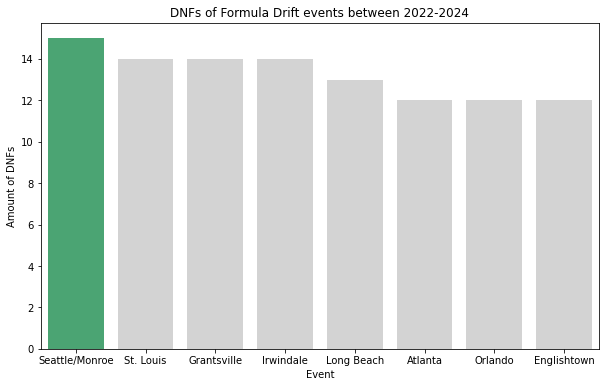

In [10]:
dnf = dnf.sort_values('Amount of DNFs', ascending=False)

colors = ['mediumseagreen' if val == dnf['Amount of DNFs'].max() else 'lightgrey' for val in dnf['Amount of DNFs']]

plt.figure(figsize=(10, 6))
sns.barplot(data=dnf, x='Event', y='Amount of DNFs', palette=colors)
plt.title('DNFs of Formula Drift events between 2022-2024')
plt.xlabel('Event')
plt.ylabel('Amount of DNFs')
plt.show()

Seattle/Monroe is the toughest event, having 15 DNFs.

## 2. What manufacturer had the highest average points per race?

In [17]:
# get average amount of points for each manufacturer into a single var
toyo = mc[mc['MANUFACTURER'] == 'TOYOTA'][['LONG BEACH', 'ATLANTA', 'ORLANDO', 'ENGLISHTOWN', 'ST. LOUIS', 'GRANTSVILLE', 'IRWINDALE', 'SEATTLE/MONROE']].mean().mean()
chevy = mc[mc['MANUFACTURER'] == 'CHEVROLET'][['LONG BEACH', 'ATLANTA', 'ORLANDO', 'ENGLISHTOWN', 'ST. LOUIS', 'GRANTSVILLE', 'IRWINDALE', 'SEATTLE/MONROE']].mean().mean()
ford = mc[mc['MANUFACTURER'] == 'FORD'][['LONG BEACH', 'ATLANTA', 'ORLANDO', 'ENGLISHTOWN', 'ST. LOUIS', 'GRANTSVILLE', 'IRWINDALE', 'SEATTLE/MONROE']].mean().mean()
nissan = mc[mc['MANUFACTURER'] == 'NISSAN'][['LONG BEACH', 'ATLANTA', 'ORLANDO', 'ENGLISHTOWN', 'ST. LOUIS', 'GRANTSVILLE', 'IRWINDALE', 'SEATTLE/MONROE']].mean().mean()
bmw = mc[mc['MANUFACTURER'] == 'BMW'][['LONG BEACH', 'ATLANTA', 'ORLANDO', 'ENGLISHTOWN', 'ST. LOUIS', 'GRANTSVILLE', 'IRWINDALE', 'SEATTLE/MONROE']].mean().mean()
dodge = mc[mc['MANUFACTURER'] == 'DODGE'][['LONG BEACH', 'ATLANTA', 'ORLANDO', 'ENGLISHTOWN', 'ST. LOUIS', 'GRANTSVILLE', 'IRWINDALE', 'SEATTLE/MONROE']].mean().mean()
ferrari = mc[mc['MANUFACTURER'] == 'FERRARI'][['LONG BEACH', 'ATLANTA', 'ORLANDO', 'ENGLISHTOWN', 'ST. LOUIS', 'GRANTSVILLE', 'IRWINDALE', 'SEATTLE/MONROE']].mean().mean()
mazda = mc[mc['MANUFACTURER'] == 'MAZDA'][['LONG BEACH', 'ATLANTA', 'ORLANDO', 'ENGLISHTOWN', 'ST. LOUIS', 'GRANTSVILLE', 'IRWINDALE', 'SEATTLE/MONROE']].mean().mean()
aston = mc[mc['MANUFACTURER'] == 'ASTON MARTIN'][['LONG BEACH', 'ATLANTA', 'ORLANDO', 'ENGLISHTOWN', 'ST. LOUIS', 'GRANTSVILLE', 'IRWINDALE', 'SEATTLE/MONROE']].mean().mean()
gm = mc[mc['MANUFACTURER'] == 'GM'][['LONG BEACH', 'ATLANTA', 'ORLANDO', 'ENGLISHTOWN', 'ST. LOUIS', 'GRANTSVILLE', 'IRWINDALE', 'SEATTLE/MONROE']].mean().mean()
cadillac = mc[mc['MANUFACTURER'] == 'CADILLAC'][['LONG BEACH', 'ATLANTA', 'ORLANDO', 'ENGLISHTOWN', 'ST. LOUIS', 'GRANTSVILLE', 'IRWINDALE', 'SEATTLE/MONROE']].mean().mean()

# put all info into a dataframe
manu = pd.DataFrame({
    'Manufacturer': ["Toyota", "Chevy", "Ford", "Nissan", "BMW", "Dodge", "Ferrari", "Mazda", "Aston", "GM", "Cadillac"],
    'Average Points': [toyo, chevy, ford, nissan, bmw, dodge, ferrari, mazda, aston, gm, cadillac]
})

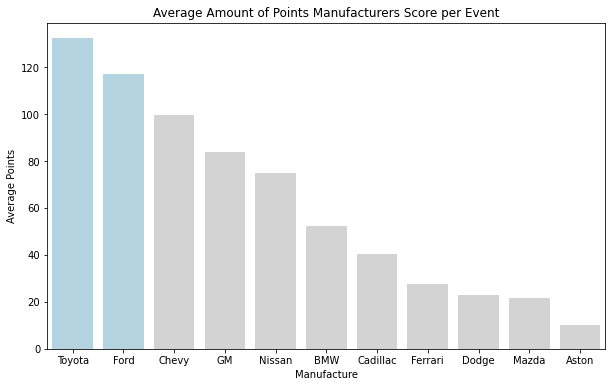

In [18]:
manu = manu.sort_values('Average Points', ascending=False)

colors = ['lightblue' if val >= manu['Average Points'][2] else 'lightgrey' for val in manu['Average Points']]

plt.figure(figsize=(10, 6))
sns.barplot(data=manu, x='Manufacturer', y='Average Points', palette=colors)
plt.title('Average Amount of Points Manufacturers Score per Event')
plt.xlabel('Manufacture')
plt.ylabel('Average Points')
plt.show()


Toyota and Ford are the 2 teams that have the highest average points scored in the series.

## 3. Is being consistent or having a higher peak performance more important in winning a championship

In [11]:
top_drivers = []

# code segment from copilot
for year in driver['Year'].unique():
    year_data = driver[driver['Year'] == year].nlargest(3, 'TOTAL')
    top_drivers.append(year_data)

top_3_drivers = pd.concat(top_drivers, ignore_index=True)

events = ['LONG BEACH', 'ATLANTA', 'ORLANDO', 'ENGLISHTOWN', 'ST. LOUIS', 'GRANTSVILLE', 'IRWINDALE', 'SEATTLE/MONROE']

# create new table to store info
analysis = []

#code segment from copilot
for idx, row in top_3_drivers.iterrows():
    year = row['Year']
    driver_name = row['DRIVER']
    
    # Get their points for each event
    event_points = [row[event] for event in events]
    
    # Calculate averages and peaks
    avg_points = sum(event_points) / len(events)
    max_event = max(event_points)
    
    # Get rank within that year
    year_rankings = top_3_drivers[top_3_drivers['Year'] == year].sort_values('TOTAL', ascending=False).reset_index(drop=True)
    rank = year_rankings[year_rankings['DRIVER'] == driver_name].index[0] + 1
    
    analysis.append({
        'Rank': rank,
        'Driver': driver_name,
        'Average Points': round(avg_points, 2),
        'Peak Points': max_event,
        'Year': year
    })

# turn analysis table into dataframe for easier viewing
top_3 = pd.DataFrame(analysis)

top_3.head(30)

,Rank,Driver,Average Points,Peak Points,Year
0,1,Fredric Aasbo Toyota ☑ / Nitto ☑,80.88,103.0,2022
1,2,Matt Field Chevrolet ☑ / Falken ☑,76.25,92.0,2022
2,3,Ryan Tuerck Toyota ☑ / Nitto ☑,71.62,103.0,2022
3,1,Chelsea DenofaFord + / Nitto +,60.00,102.0,2023
4,2,Aurimas BakchisNissan / GT Radial +,55.62,100.0,2023
5,3,Matt FieldChevrolet + / GT Radial +,53.38,100.0,2023
6,1,James Deane,83.25,100.0,2024
7,2,Aurimas Bakchis,68.50,100.0,2024
8,3,Fredric Aasbo,65.00,100.0,2024


Overall, it seems that the average amount of poitns matters more in a championship, as the peak points generally are around 100 for each competitor.

## 4. How important is the first round when it comes to overall points scored?

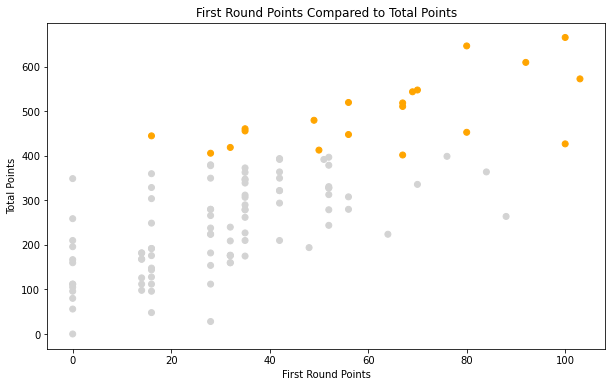

In [12]:
q3 = driver.sort_values(by='LONG BEACH', ascending=True).reset_index(drop=True)

q3['LONG BEACH'] = pd.to_numeric(driver['LONG BEACH'], errors='coerce') # code segment from copilot
q3['TOTAL'] = pd.to_numeric(driver['TOTAL'], errors='coerce')

x = q3['LONG BEACH']
y = q3['TOTAL']

colors = ['orange' if val > 400 else 'lightgrey' for val in q3['TOTAL']]
plt.figure(figsize=(10, 6))
plt.scatter(x, y, color=colors)
plt.title("First Round Points Compared to Total Points")
plt.xlabel("First Round Points")
plt.ylabel("Total Points")
plt.show()

There seems to be no correlation between first round points and total points scored. The distribution has a very wide range.